<a href="https://colab.research.google.com/github/vera2005/mlLessonCAT_VS_DOG/blob/main/%D0%A3%D0%A0%D0%9E%D0%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ячейка 1: Импорт библиотек
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds

In [ ]:
# Ячейка 2: Загрузка датасета кошек и собак (сделано в Google) (скачивание занимает пару минут)
print("Загрузка датасета (25000 картинок)...")
(train_ds, test_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]'],  # 80% на обучение, 10% на проверку
    as_supervised=True,
    with_info=True
)

print(f"Тренировочных: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Тестовых: {tf.data.experimental.cardinality(test_ds).numpy()}")
print(f"Метки: 0 = собака, 1 = кошка")

Загрузка датасета (25000 картинок)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.H0X2MX_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Тренировочных: 18610
Тестовых: 2326
Метки: 0 = собака, 1 = кошка


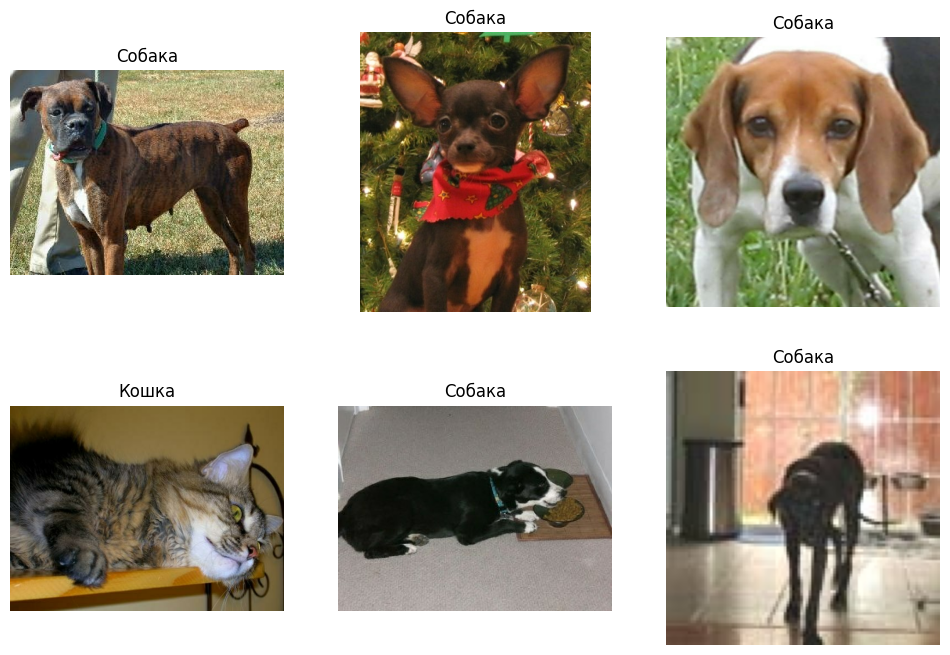

In [ ]:
# Ячейка 3: Покажем несколько примеров
plt.figure(figsize=(12, 8))
for i, (image, label) in enumerate(train_ds.take(6)):
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title("Кошка" if label == 0 else "Собака")
    plt.axis('off')
plt.show()

In [ ]:
# Ячейка 4: Подготовка данных (изменение размера, нормализация)
IMG_SIZE = 150
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0   # нормализуем в [0,1]
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Данные готовы к обучению")

Данные готовы к обучению


In [ ]:
# Ячейка 5: Создаём простую свёрточную сеть
model = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Ячейка 6: Обучение (5 эпох, хватит для демонстрации) (займет много минут, очень много)
history = model.fit(train_ds,
                    validation_data=test_ds,
                    epochs=5,
                    verbose=1)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 292s 495ms/step - accuracy: 0.6592 - loss: 0.6114 - val_accuracy: 0.7696 - val_loss: 0.5078
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 302s 518ms/step - accuracy: 0.7809 - loss: 0.4617 - val_accuracy: 0.7648 - val_loss: 0.4806
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 296s 507ms/step - accuracy: 0.8261 - loss: 0.3848 - val_accuracy: 0.7829 - val_loss: 0.4835
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 296s 507ms/step - accuracy: 0.8672 - loss: 0.3077 - val_accuracy: 0.8117 - val_loss: 0.4459
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 291s 498ms/step - accuracy: 0.9129 - loss: 0.2120 - val_accuracy: 0.8078 - val_loss: 0.5510


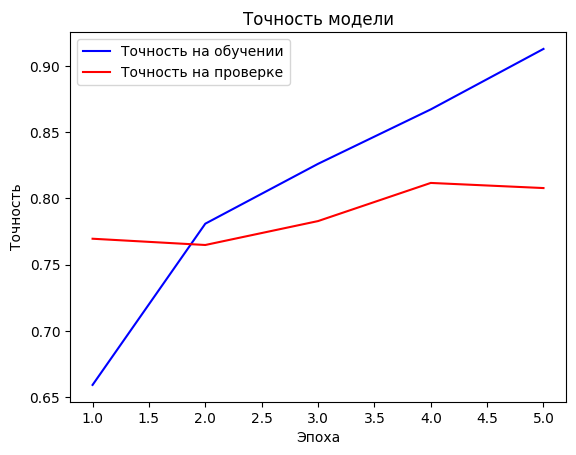

In [ ]:
# Ячейка 7: График точности
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc)+1)

plt.plot(epochs_range, acc, 'b', label='Точность на обучении')
plt.plot(epochs_range, val_acc, 'r', label='Точность на проверке')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


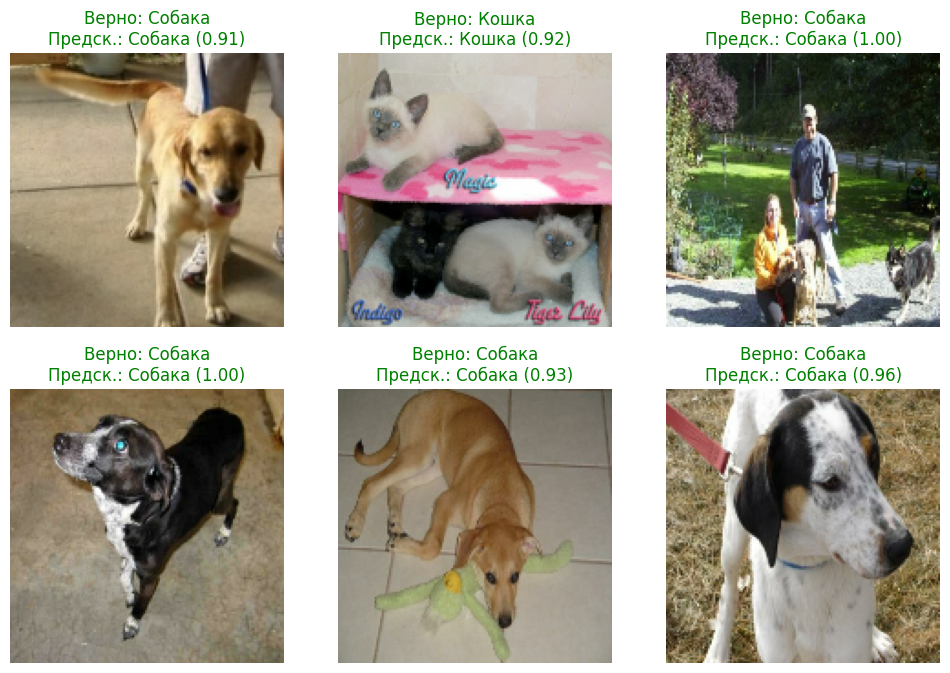

In [ ]:
# Ячейка 8: Проверяем на случайных картинках из теста
plt.figure(figsize=(12, 8))
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy())
        true_label = "Кошка" if labels[i] == 0 else "Собака"   # 1 - кошка, 0 - собака
        pred_label = "Кошка" if preds[i][0] < 0.5 else "Собака"
        prob = preds[i][0] if preds[i][0] > 0.5 else 1 - preds[i][0]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Верно: {true_label}\nПредск.: {pred_label} ({prob:.2f})", color=color)
        plt.axis('off')
plt.show()

Saving cat5.jpg to cat5 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


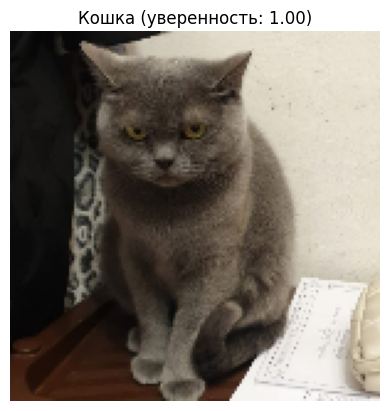

In [ ]:
# Ячейка 9 (бонус): Загрузите своё фото кошки или собаки
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    img = keras.utils.load_img(fn, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0

    pred = model.predict(img_array)[0][0]
    label = "Кошка" if pred < 0.5 else "Собака"
    conf = pred if pred > 0.5 else 1 - pred

    plt.imshow(img)
    plt.title(f"{label} (уверенность: {conf:.2f})")
    plt.axis('off')
    plt.show()